In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import connected_components

import pickle
from joblib import Parallel, delayed

# Load data

In [ ]:
spatial = pd.read_csv(r'..\..\results\cell_type_annotation\v4\xenium_7202d_spatial_annotation.csv')

# knn graph, filter outlier cells

In [650]:
k = 5
adj_matrix = kneighbors_graph(spatial[['x_centroid','y_centroid']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [651]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [652]:
np.unique(labels, return_counts=True)

(array([0, 1]), array([20998,    20], dtype=int64))

In [653]:
# Initially, only keep the largest subgraph, unless there are other large subgraphs
valid_components = [0]
valid_nodes = np.isin(labels, valid_components)
adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
filtered_points = spatial.iloc[valid_nodes]

In [654]:
filtered_points.reset_index(drop=True, inplace=True)

In [655]:
filtered_points.shape

(20998, 12)

In [656]:
adj_matrix.shape

(20998, 20998)

In [677]:
# Remove the longest k edges
distances = adj_matrix.data
row, col = adj_matrix.nonzero()
k_remove = 4
longest_edge_indices = np.argsort(distances)[-k_remove:]

In [678]:
for idx in longest_edge_indices:
    adj_matrix[row[idx], col[idx]] = 0
    adj_matrix[col[idx], row[idx]] = 0
adj_matrix.eliminate_zeros()

In [679]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [680]:
n_components

2

In [681]:
# Long edges and associated small subgraphs are removed here
valid_components = [0]
valid_nodes = np.isin(labels, valid_components)
adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
filtered_points = filtered_points.iloc[valid_nodes]
filtered_points.reset_index(drop=True, inplace=True)

In [682]:
filtered_points.shape

(20994, 12)

(479.7645721435547, 3015.689224243164, 331.4649810791016, 2692.3436737060547)

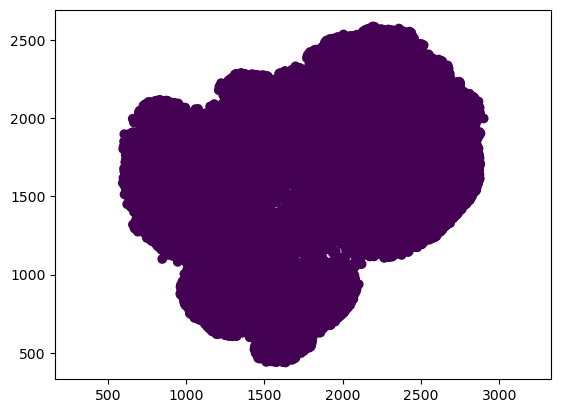

In [683]:
# visually inspect the graph
plt.scatter(filtered_points['x_centroid'], filtered_points['y_centroid'], c=labels[valid_nodes])
plt.axis('equal')

In [684]:
filtered_points.to_csv(r'..\..\results\graph_classification\xenium\xenium_7202d_spatial_annotation_filtered.csv', index=False)

In [685]:
row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [686]:
with open(r'..\..\results\graph_classification\xenium\xenium_7202d_spatial_annotation_filtered_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

In [687]:
filtered_points.shape

(20994, 12)

In [688]:
np.max(unique_edges)

20993

# extract 3-hop subgraphs around stromal cells

## example and 83a

In [2]:
filtered_points = pd.read_csv(r'..\..\..\results\graph_classification_v5\xenium\xenium_83a_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\..\results\graph_classification_v5\xenium\xenium_83a_spatial_annotation_filtered_edges.pkl')

In [3]:
def one_hop_neighbors(cell, cell_metadata, edges):
    idx = cell_metadata.index.get_loc(cell)
    neighbors = set()
    for edge in edges:
        if edge[0] == idx:
            neighbors.add(edge[1])
        elif edge[1] == idx:
            neighbors.add(edge[0])
    # neighbor_cells = []
    # for items in neighbors:
    #     neighbor_cells.append(cell_metadata.index[items])
    return list(neighbors)

def two_hop_neighbors(cell, cell_metadata, edges):
    one_hop = one_hop_neighbors(cell, cell_metadata, edges)
    two_hop = set()

    for neighbor in one_hop:
        two_hop.update(one_hop_neighbors(neighbor, cell_metadata, edges))
    
    two_hop.update(one_hop)
    # two_hop.discard(cell_metadata.index.get_loc(cell))
    return list(two_hop)

def three_hop_neighbors(cell, cell_metadata, edges):
    two_hop = two_hop_neighbors(cell, cell_metadata, edges)
    three_hop = set()
    for neighbor in two_hop:
        three_hop.update(one_hop_neighbors(neighbor, cell_metadata, edges))

    three_hop.update(two_hop)
    # three_hop.discard(cell_metadata.index.get_loc(cell))
    return list(three_hop)

def edges_in_subgraph(neighborhood, edges):
    neighborhood = set(neighborhood)
    subgraph_edges = []
    for edge in edges:
        if edge[0] in neighborhood and edge[1] in neighborhood:
            subgraph_edges.append(edge)
    return subgraph_edges

In [4]:
from collections import defaultdict, deque

def build_adjacency_list(edges, num_nodes):
    adj = defaultdict(set)
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)
    return adj

def k_hop_neighbors(cell, cell_metadata, edges, k):
    idx = cell_metadata.index.get_loc(cell)
    num_nodes = len(cell_metadata)
    adj = build_adjacency_list(edges, num_nodes)

    visited = set([idx])
    queue = deque([(idx, 0)])
    
    while queue:
        current, depth = queue.popleft()
        if depth >= k:
            continue
        for neighbor in adj[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))

    return list(visited)

In [5]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [6]:
i = 155
two_hop = k_hop_neighbors(cells_idx[i], filtered_points, unique_edges, 3)

In [7]:
cells_idx[155]

22433

In [8]:
filtered_points.iloc[cells_idx[155]]

cell_id                        ejedhmpn-1
x_centroid                     232.297623
y_centroid                    2260.197998
transcript_counts                      33
control_probe_counts                    0
control_codeword_counts                 0
unassigned_codeword_counts              0
deprecated_codeword_counts              0
total_counts                           33
cell_area                       20.907345
nucleus_area                    13.095313
cell_types                        Stromal
Name: 22433, dtype: object

In [9]:
edges = edges_in_subgraph(two_hop, unique_edges)

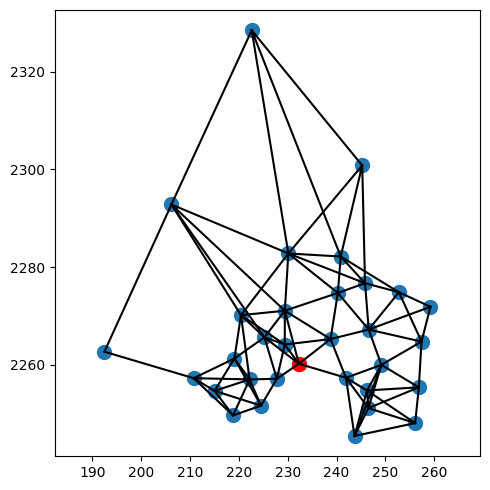

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for edge in edges:
    ax.plot(filtered_points['x_centroid'].iloc[edge], filtered_points['y_centroid'].iloc[edge], c='black')
ax.scatter(filtered_points['x_centroid'].iloc[two_hop], filtered_points['y_centroid'].iloc[two_hop], s=100)
ax.scatter(filtered_points['x_centroid'].iloc[cells_idx[i]], filtered_points['y_centroid'].iloc[cells_idx[i]], c='red', s=100)

ax.axis('equal')
plt.tight_layout()
# plt.savefig(r'..\..\figures\graph_classification\stromal_subgraph.png', dpi=300)

In [11]:
filtered_points.iloc[edges[0][0]]['cell_id']

'ebcjjaan-1'

In [12]:
edges_by_id = []
for item in edges:
    edges_by_id.append((filtered_points.iloc[item[0]]['cell_id'], filtered_points.iloc[item[1]]['cell_id'])) 

In [13]:
# Processing function
def sub_graphs(cell, cell_metadata, edges):
    three_hop = k_hop_neighbors(cell, cell_metadata, edges, 3)

    three_hop_edges = edges_in_subgraph(three_hop, edges)
    three_hop_edges_by_id = []
    for item in three_hop_edges:
        three_hop_edges_by_id.append((cell_metadata.iloc[item[0]]['cell_id'], cell_metadata.iloc[item[1]]['cell_id']))

    return three_hop_edges_by_id

In [14]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [15]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_83a.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [16]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_83a_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 83b

In [17]:
filtered_points = pd.read_csv(r'..\..\..\results\graph_classification_v5\xenium\xenium_83b_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\..\results\graph_classification_v5\xenium\xenium_83b_spatial_annotation_filtered_edges.pkl')

In [18]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [19]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

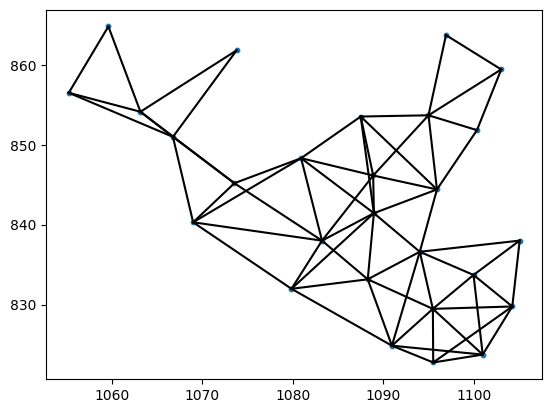

In [20]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [21]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_83b.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [22]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_83b_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 84a

In [23]:
filtered_points = pd.read_csv(r'..\..\..\results\graph_classification_v5\xenium\xenium_84a_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\..\results\graph_classification_v5\xenium\xenium_84a_spatial_annotation_filtered_edges.pkl')

In [24]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [25]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

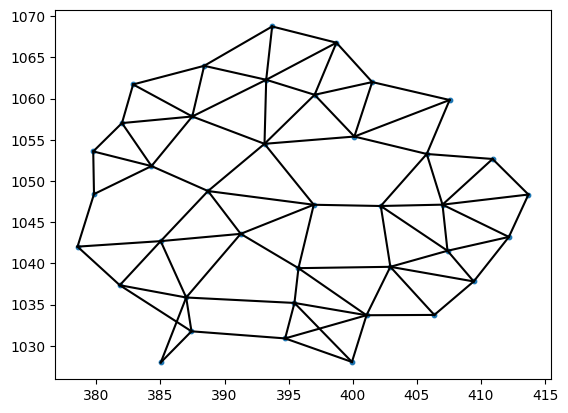

In [26]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [27]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_84a.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [28]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_84a_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 84b

In [29]:
filtered_points = pd.read_csv(r'..\..\..\results\graph_classification_v5\xenium\xenium_84b_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\..\results\graph_classification_v5\xenium\xenium_84b_spatial_annotation_filtered_edges.pkl')

In [30]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [31]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

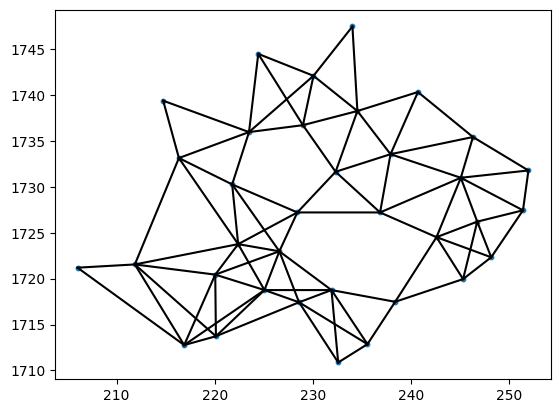

In [32]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [33]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_84b.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [34]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_84b_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 174c

In [35]:
filtered_points = pd.read_csv(r'..\..\..\results\graph_classification_v5\xenium\xenium_174c_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\..\results\graph_classification_v5\xenium\xenium_174c_spatial_annotation_filtered_edges.pkl')

In [36]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [37]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

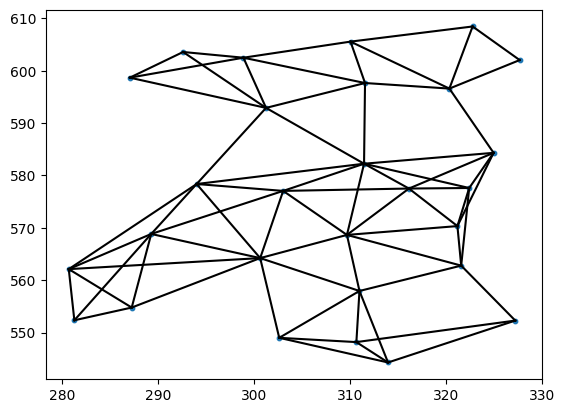

In [38]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [39]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_174c.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [40]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_174c_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 174d

In [41]:
filtered_points = pd.read_csv(r'..\..\..\results\graph_classification_v5\xenium\xenium_174d_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\..\results\graph_classification_v5\xenium\xenium_174d_spatial_annotation_filtered_edges.pkl')

In [42]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [43]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.17685508728027344s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]

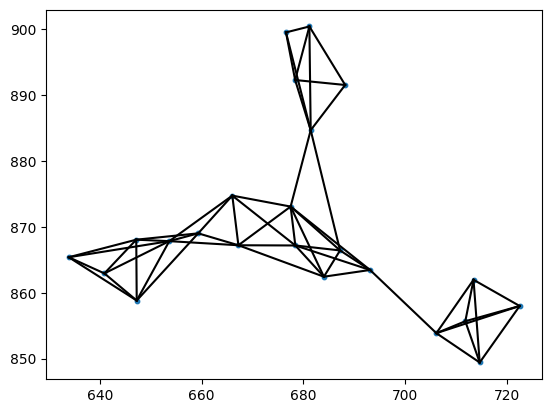

In [44]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [45]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_174d.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [46]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_174d_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 7202c

In [59]:
filtered_points = pd.read_csv(r'..\..\..\results\graph_classification_v5\xenium\xenium_7202c_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\..\results\graph_classification_v5\xenium\xenium_7202c_spatial_annotation_filtered_edges.pkl')

In [60]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [61]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

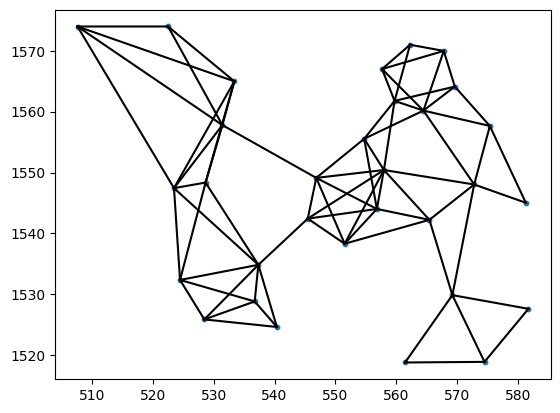

In [62]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [63]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_7202c.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [64]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_7202c_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 7202d

In [53]:
filtered_points = pd.read_csv(r'..\..\..\results\graph_classification_v5\xenium\xenium_7202d_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\..\results\graph_classification_v5\xenium\xenium_7202d_spatial_annotation_filtered_edges.pkl')

In [54]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [55]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

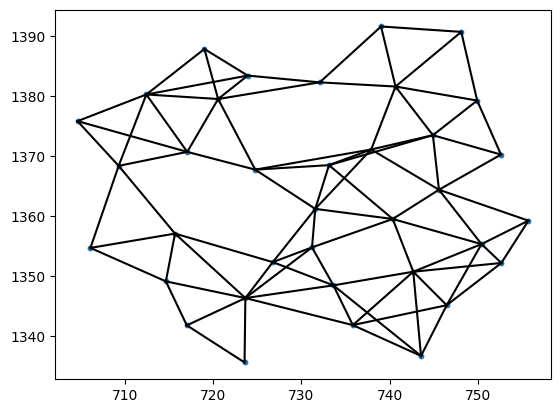

In [56]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell_id'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['x_centroid'], nodes['y_centroid'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell_id'] == node1]['x_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['x_centroid'].values[0]],
             [filtered_points[filtered_points['cell_id'] == node1]['y_centroid'].values[0], filtered_points[filtered_points['cell_id'] == node2]['y_centroid'].values[0]], c='black')

In [57]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_7202d.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [58]:
with open(r'..\..\..\results\tunable_neighborhood\xenium\3hop\sub_graphs_7202d_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

# Cosmx

# filter ourlier points

In [2]:
spatial = pd.read_csv(r"Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\cell_type_annotation\v3\cosmx_7202-2_spatial_annotation.csv")

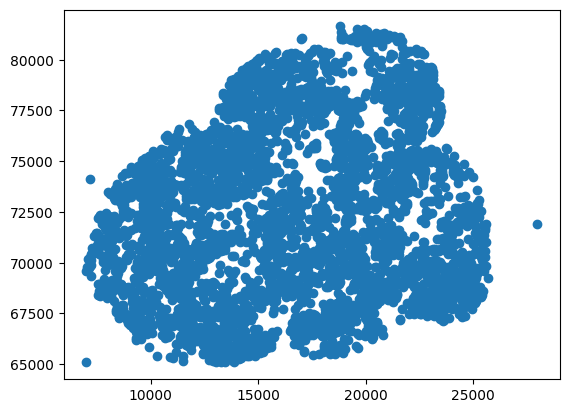

In [5]:
plt.scatter(spatial['CenterX_global_px'].tolist(), spatial['CenterY_global_px'].tolist())

In [625]:
k = 5
adj_matrix = kneighbors_graph(spatial[['CenterX_global_px','CenterY_global_px']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [626]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [627]:
np.unique(labels, return_counts=True)

(array([0, 1], dtype=int32), array([4462,   10]))

In [628]:
filtered_points = spatial

In [629]:
# Initially, only keep the largest subgraph, unless there are other large subgraphs
valid_components = [0]
valid_nodes = np.isin(labels, valid_components)
adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
filtered_points = spatial.iloc[valid_nodes]

In [630]:
filtered_points.reset_index(drop=True, inplace=True)

In [631]:
filtered_points.shape

(4462, 59)

In [632]:
adj_matrix.shape

(4462, 4462)

In [662]:
# Remove the longest k edges
distances = adj_matrix.data
row, col = adj_matrix.nonzero()
k_remove = 3
longest_edge_indices = np.argsort(distances)[-k_remove:]

In [663]:
for idx in longest_edge_indices:
    adj_matrix[row[idx], col[idx]] = 0
    adj_matrix[col[idx], row[idx]] = 0
adj_matrix.eliminate_zeros()

In [664]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [665]:
n_components

2

In [666]:
np.unique(labels, return_counts=True)

(array([0, 1], dtype=int32), array([4459,    1]))

In [667]:
# Long edges and associated small subgraphs are removed here
valid_components = [0]
valid_nodes = np.isin(labels, valid_components)
adj_matrix = adj_matrix[valid_nodes][:, valid_nodes]
filtered_points = filtered_points.iloc[valid_nodes]
filtered_points.reset_index(drop=True, inplace=True)

In [668]:
filtered_points.shape

(4459, 59)

(np.float64(6061.5514879847215),
 np.float64(26632.65125754989),
 np.float64(64258.10178867323),
 np.float64(82466.40161584718))

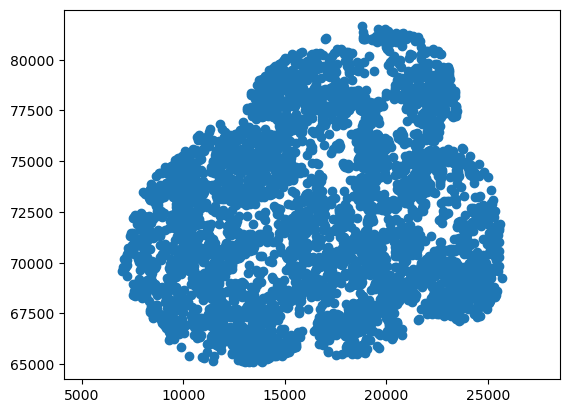

In [669]:
# visually inspect the graph
plt.scatter(filtered_points['CenterX_global_px'], filtered_points['CenterY_global_px'])#, c=labels[valid_nodes])
plt.axis('equal')

In [670]:
filtered_points.to_csv(r'..\..\results\graph_classification\cosmx\cosmx_7202-2_spatial_annotation_filtered.csv', index=False)

In [671]:
row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [672]:
with open(r'..\..\results\graph_classification\cosmx\cosmx_7202-2_spatial_annotation_filtered_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

# subgraphs and 2-hop neighbors

## example, 83

In [676]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification\cosmx\cosmx_83_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification\cosmx\cosmx_83_spatial_annotation_filtered_edges.pkl')

In [677]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [678]:
i = 155
two_hop = two_hop_neighbors(cells_idx[155], filtered_points, unique_edges)

In [679]:
cells_idx[155]

4656

In [680]:
filtered_points.iloc[cells_idx[155]]

fov                                                                        9
Area                                                                    7077
AspectRatio                                                             1.13
CenterX_local_px                                                        1602
CenterY_local_px                                                        2174
Width                                                                    101
Height                                                                    89
Mean.PanCK                                                               513
Max.PanCK                                                               3960
Mean.G                                                                   247
Max.G                                                                  12320
Mean.Membrane                                                            829
Max.Membrane                                                            4948

In [681]:
edges = edges_in_subgraph(two_hop, unique_edges)

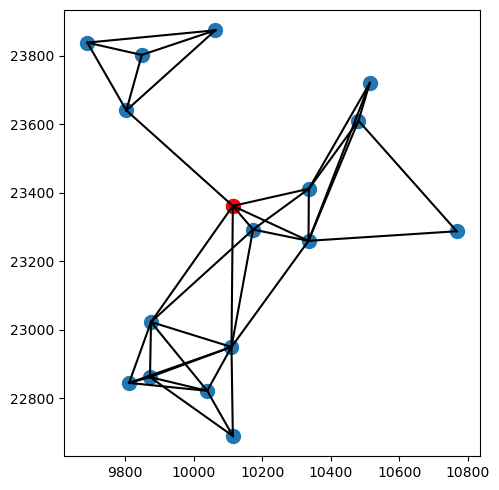

In [683]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for edge in edges:
    ax.plot(filtered_points['CenterX_global_px'].iloc[edge], filtered_points['CenterY_global_px'].iloc[edge], c='black')
ax.scatter(filtered_points['CenterX_global_px'].iloc[two_hop], filtered_points['CenterY_global_px'].iloc[two_hop], s=100)
ax.scatter(filtered_points['CenterX_global_px'].iloc[cells_idx[i]], filtered_points['CenterY_global_px'].iloc[cells_idx[i]], c='red', s=100)

ax.axis('equal')
plt.tight_layout()
# plt.savefig(r'..\..\figures\graph_classification\stromal_subgraph.png', dpi=300)

In [684]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [685]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_83.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [686]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_83_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 84

In [3]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification\cosmx\cosmx_84_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification\cosmx\cosmx_84_spatial_annotation_filtered_edges.pkl')

In [4]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [7]:
cells

,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.G,...,unassignedTranscripts,nCount_RNA,nFeature_RNA,nCount_negprobes,nFeature_negprobes,nCount_falsecode,nFeature_falsecode,Area.um2,cell,cell_types
92,1,4911,1.05,3665,2581,83,79,54,164,12,...,0.165036,6,5,0,0,0,0,71.049921,c_2_1_98,Stromal
121,1,11913,0.98,1657,3754,131,133,135,1152,47,...,0.165036,11,9,0,0,0,0,172.351396,c_2_1_132,Stromal
127,1,4553,0.57,1549,3908,60,106,1203,2732,496,...,0.165036,11,10,0,0,0,0,65.870554,c_2_1_139,Stromal
131,1,3384,0.88,1606,3937,66,75,2022,3052,823,...,0.165036,5,4,0,0,1,1,48.958039,c_2_1_143,Stromal
154,1,8459,1.26,3987,4202,135,107,18,600,40,...,0.165036,45,37,0,0,0,0,122.380631,c_2_1_169,Stromal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30346,33,2387,1.14,3790,1910,67,59,221,796,61,...,0.055831,101,90,0,0,0,0,34.533936,c_2_33_271,Stromal
30350,33,4789,0.79,3931,1977,76,96,169,880,51,...,0.055831,111,92,0,0,0,0,69.284885,c_2_33_275,Stromal
30356,33,4557,1.42,3993,2032,98,69,46,584,12,...,0.055831,20,16,0,0,0,0,65.928424,c_2_33_281,Stromal
30373,33,2465,2.31,3933,2278,90,39,148,780,51,...,0.055831,15,12,0,0,0,0,35.662402,c_2_33_298,Stromal


In [693]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [694]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_84.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [695]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_84_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 174-1

In [14]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification\cosmx\cosmx_174-1_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification\cosmx\cosmx_174-1_spatial_annotation_filtered_edges.pkl')

In [15]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [19]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [699]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_174-1.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [701]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_174-1_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 174-2

In [702]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification\cosmx\cosmx_174-2_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification\cosmx\cosmx_174-2_spatial_annotation_filtered_edges.pkl')

In [703]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [704]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.13100314140319824s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [705]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_174-2.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [706]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_174-2_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 7202-1

In [707]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification\cosmx\cosmx_7202-1_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification\cosmx\cosmx_7202-1_spatial_annotation_filtered_edges.pkl')

In [708]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [709]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [710]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_7202-1.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [712]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_7202-1_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## 7202-2

In [713]:
filtered_points = pd.read_csv(r'..\..\results\graph_classification\cosmx\cosmx_7202-2_spatial_annotation_filtered.csv')
unique_edges = pd.read_pickle(r'..\..\results\graph_classification\cosmx\cosmx_7202-2_spatial_annotation_filtered_edges.pkl')

In [714]:
cells = filtered_points[filtered_points['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [715]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.17158985137939453s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [716]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_7202-2.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [717]:
with open(r'..\..\results\graph_classification\cosmx\sub_graphs_7202-2_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)